In [3]:

import networkx as nx
import osmnx as ox
import matplotlib.cm as cm
import matplotlib.colors as colors
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import folium
import geopandas as gpd

  Using cached osmnx-1.9.3-py3-none-any.whl (107 kB)


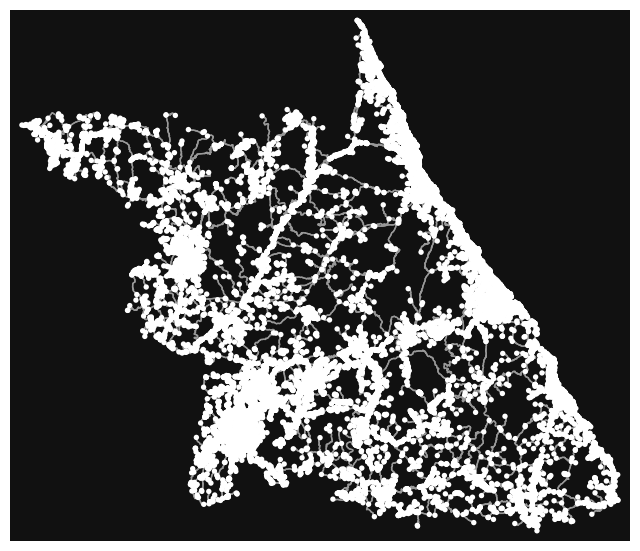

In [4]:
G = ox.graph_from_place('강원특별자치도, 대한민국', network_type = 'drive')
fig, ax = ox.plot_graph(G)

In [5]:
G_proj = ox.project_graph(G)

In [10]:
import osmnx as ox
import pandas as pd

# 지리적 데이터가 포함된 CSV 파일 읽기
data = pd.read_csv('../data/exist_filtered.csv')

# 강원특별자치도에 대한 그래프 로드
G = ox.graph_from_place('강원특별자치도, 대한민국', network_type='drive')
G_proj = ox.project_graph(G)

# 각 시설의 위도와 경도를 사용하여 가장 가까운 노드 찾기
def find_nearest_nodes(df, graph):
    nodes = []
    for _, row in df.iterrows():
        node = ox.nearest_nodes(graph, row['경도'], row['위도'])
        nodes.append(node)
    return nodes

data['nearest_node'] = find_nearest_nodes(data, G_proj)

# 결과 확인
print(data[['도로명주소', '위도', '경도', 'nearest_node']])

# 결과를 CSV 파일로 저장
data.to_csv('../data/updated_data_with_nodes.csv', index=False)


                        도로명주소         위도          경도  nearest_node
0         강원도 춘천시 영서로 2473     37.880234  127.710857    3866297229
1    강원도 춘천시 신북읍 율문리 935-122   37.923463  127.742307    3866297229
2        강원도 춘천시 남산면 방곡리 산64   37.807063  127.643994    3866297229
3     강원도 춘천시 서면 금산리 1120-24   37.899351  127.696634    3866297229
4       강원도 춘천시 사북면 신포리 164-5  38.023148  127.645140    3866297229
..                        ...        ...         ...           ...
130           강원도 원주시 호저로 113  37.386789  127.939983    3866297229
131      강원도 철원군 갈말읍 지포2길 146  38.130821  127.289909    3866297229
132       강원도 홍천군 북방면 소매곡길 12  37.707132  127.837152    3866297229
133       강원도 홍천군 북방면 소매곡길 12  37.707132  127.837152    3866297229
134          횡성군 서원면 금대남2길 55  37.491190  127.908843    3866297229

[135 rows x 4 columns]


In [11]:
import pandas as pd

# 데이터 불러오기
data = pd.read_csv('../data/exist_filtered.csv')

# 춘천시 데이터만 필터링
chuncheon_data = data[data['시군'] == '춘천시']

# 결과 확인
print(chuncheon_data.head())

# 선택적으로 결과를 새로운 CSV 파일로 저장
chuncheon_data.to_csv('../data/chuncheon_data.csv', index=False)


        구분   유형   시도   시군     시설명      시설용량                     도로명주소  \
1   하수처리시설  NaN  강원도  춘천시      춘천  150000.0  강원도 춘천시 신북읍 율문리 935-122    
23  하수처리시설  NaN  강원도  춘천시      신북    4500.0     강원도 원주시 신림면 용암리 1244    
25  하수처리시설  NaN  강원도  춘천시      강촌    4000.0        원주시 귀래면 운남리 946-1    
32  하수처리시설  NaN  강원도  춘천시      서면    1900.0         원주시 지정면 신평리 1043    
66  하수처리시설  NaN  강원도  춘천시  지촌 신포리     490.0            강원도 태백시 조탄동 68   

           위도          경도  소권역  연간처리량  
1   37.923463  127.742307  NaN    NaN  
23  37.210326  128.093973  NaN    NaN  
25  37.168000  127.884410  NaN    NaN  
32  37.366063  127.896757  NaN    NaN  
66  37.326070  128.970383  NaN    NaN  


In [13]:
# 파일을 불러와서 데이터를 확인한다.
import pandas as pd

# 데이터를 불러오는 코드
file_path = '../data/exist.csv'
data = pd.read_csv(file_path)

# 데이터의 처음 몇 줄과 구조를 출력하여 확인한다.
data.head(), data.columns

# 춘천시 데이터 중에서 '바이오가스화시설'을 제외하고 필터링한다.
filtered_data = data[(data['시군'] == '춘천시') & (data['구분'] != '바이오가스화시설')]

# 새로운 CSV 파일로 저장한다.
filtered_file_path = '../data/chuncheon_data.csv'
filtered_data.to_csv(filtered_file_path, index=False)

filtered_file_path

# 데이터를 UTF-8 형식으로 인코딩하여 다시 저장한다.
utf8_filtered_file_path = '../data/chuncheon_data_utf8.csv'
filtered_data.to_csv(utf8_filtered_file_path, index=False, encoding='utf-8-sig')

utf8_filtered_file_path


'chuncheon_data_utf8.csv'

In [30]:
import osmnx as ox
import networkx as nx
import pandas as pd
from shapely.geometry import Point
import sklearn


# UTF-8로 저장된 춘천 지역 데이터를 불러온다.
chuncheon_data = pd.read_csv('../data/chuncheon_data.csv')

# 데이터에서 위도와 경도 정보를 추출한다.
latitudes = chuncheon_data['위도'].tolist()
longitudes = chuncheon_data['경도'].tolist()

latitudes, longitudes

([37.8802344,
  37.9234628,
  37.8070633,
  37.8993514,
  38.0231483,
  37.79736,
  37.9681247,
  37.9472665,
  37.9731123,
  37.7385256,
  37.7347611,
  37.7379515,
  37.8407908,
  37.959415,
  37.7673627,
  37.8583865,
  37.9922018,
  37.8802344,
  37.8802344],
 [127.7108568,
  127.7423067,
  127.6439939,
  127.6966335,
  127.64514,
  127.7734092,
  127.6660425,
  127.7301528,
  127.5973918,
  127.5970568,
  127.5752705,
  127.7944485,
  127.5527164,
  127.6836881,
  127.802972,
  127.6168312,
  127.7024805,
  127.7108568,
  127.7108568])

In [31]:
def find_nearest_road_nodes(latitudes, longitudes, place = 'Chuncheon, South Korea'):
    # 해당 지역의 도로 네트워크를 불러온다
    G = ox.graph_from_place(place, network_type = 'drive')
    
    # 각 좌표에 대해 가장 가까운 노드를 찾는다
    nearest_nodes = []
    for lat, lon in zip(latitudes, longitudes):
        point = Point(lon, lat)
        nearest_node = ox.distance.nearest_nodes(G, X=point.x, Y=point.y)
        nearest_nodes.append(G.nodes[nearest_node])
    
    # 결과를 DataFrame으로 반환한다
    return pd.DataFrame(nearest_nodes)

# 사용 예시
nearest_nodes_df = find_nearest_road_nodes(latitudes, longitudes)

print(nearest_nodes_df)


ImportError: scikit-learn must be installed to search an unprojected graph

In [32]:
import pandas as pd

# 파일 경로
file_path = '../data/chuncheon_data.csv'

# CSV 파일 로드
data = pd.read_csv(file_path)

# 데이터의 처음 몇 줄을 출력하여 확인
data.head()

,구분,유형,시도,시군,시설명,시설용량,도로명주소,위도,경도,소권역,연간처리량
0,하수처리시설,NaN,강원도,춘천시,춘천,150000.0,강원도 춘천시 영서로 2473,37.880234,127.710857,NaN,NaN
1,하수처리시설,NaN,강원도,춘천시,신북,4500.0,강원도 춘천시 신북읍 율문리 935-122,37.923463,127.742307,NaN,NaN
2,하수처리시설,NaN,강원도,춘천시,강촌,4000.0,강원도 춘천시 남산면 방곡리 산64,37.807063,127.643994,NaN,NaN
3,하수처리시설,NaN,강원도,춘천시,서면,1900.0,강원도 춘천시 서면 금산리 1120-24,37.899351,127.696634,NaN,NaN
4,하수처리시설,NaN,강원도,춘천시,지촌 신포리,490.0,강원도 춘천시 사북면 신포리 164-5,38.023148,127.645140,NaN,NaN


In [33]:
import osmnx as ox
import pandas as pd

# 데이터 로드
data = pd.read_csv('../data/chuncheon_data.csv')

# 춘천시의 위도와 경도를 중심으로 하는 그래프를 로드
G = ox.graph_from_point((37.8813, 127.7298), dist=10000, network_type='drive')

# 각 좌표에 대해 가장 가까운 노드 번호를 찾기
data['nearest_node'] = data.apply(lambda row: ox.nearest_nodes(G, row['경도'], row['위도']), axis=1)

# 결과 출력
print(data[['위도', '경도', 'nearest_node']])


ImportError: scikit-learn must be installed to search an unprojected graph